### Credit Card Fraud Dectection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# Dataset
X = [[1,300,2],[2,180,3],[1,240,1],[3,120,4],[8,5,18],[7,10,15],[9,8,20],[6,15,14],[5,60,10],[4,80,7],[6,40,9],[5,20,12],[2,200,2],[7,12,16],[3,100,5]]
y = [0,0,0,0,1,1,1,1,1,0,0,1,0,1,0]

In [3]:
# Prediction function
def predict(x,w,b):
    score = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b

    if score>=0:
        return 1
    
    else:
        return 0

In [4]:
# Computing accuracy
def compute(X,y,w,b):
    correct = 0

    for i in range(len(X)):
        pred = predict(X[i],w,b)

        if pred == y[i]:
            correct+=1

    return correct/len(X)

In [5]:
# Random Search
best_acc = 0
best_w = None
best_b = None

for _ in range(50000):
    w = [random.uniform(-10,10), random.uniform(-10,10), random.uniform(-10,10)]
    b = random.uniform(-10,10)

    acc = compute(X,y,w,b)

    if acc>best_acc:
        best_acc = acc
        best_w = w
        best_b = b

print("Best Weights: ", best_w)
print("Best Bias: ", best_b)
print("Best Accuracy: ", best_acc)

Best Weights:  [-6.5519531260510755, -0.03989609355016199, 5.03097367886596]
Best Bias:  -9.552231069566332
Best Accuracy:  1.0


In [6]:
# Inspect the mistakes caused by noisy data
for i in range(len(X)):
    pred = predict(X[i],best_w,best_b)

    if pred!=y[i]:
        print("Misclassified: ", X[i],
              "Actual: ", y[i],
              "Predicted: ", pred)

In [7]:
# Normalize the features
X_np = np.array(X)

means = np.mean(X_np,axis=0)
stds = np.std(X_np, axis=0)

X_scaled = (X_np-means)/stds

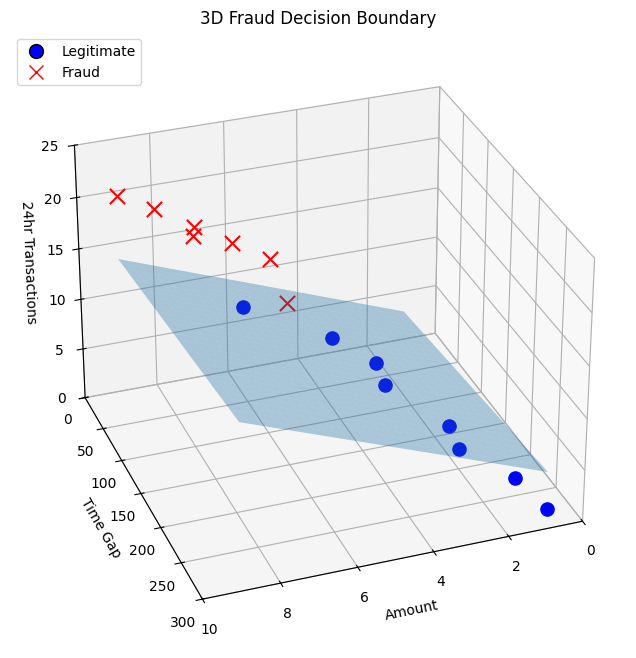

In [24]:
from matplotlib.lines import Line2D

# Plot the dataset
X = np.array(X)
y = np.array(y)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(X)):
    if y[i]==0:
        ax.scatter(X[i,0],X[i,1],X[i,2], marker='o', color="blue", s=90)
    
    else:
        ax.scatter(X[i,0],X[i,1],X[i,2], marker='x', color="red", s=120)
        

# Plot the decision boundary
w1,w2,w3 = best_w
b = best_b

x_range = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    30
)

y_range = np.linspace(
    X[:,1].min(),
    X[:,1].max(),
    30
)

X_grid,Y_grid = np.meshgrid(x_range,y_range)


if abs(w3)>1e-8:
    Z_grid = -(w1*X_grid+w2*Y_grid+b)/w3

    ax.plot_surface(
        X_grid,
        Y_grid,
        Z_grid,
        alpha=0.35,
        shade=True
    )

ax.view_init(
    elev=30,
    azim=70
)

# axis limits
ax.set_xlim(0,10)
ax.set_ylim(0,300)
ax.set_zlim(0,25)


# Label
ax.set_title("3D Fraud Decision Boundary")
ax.set_xlabel("Amount")
ax.set_ylabel("Time Gap")
ax.set_zlabel("24hr Transactions")


# ----------------------------
# Legend
# ----------------------------

legend_elements=[

Line2D(
[0],[0],
marker='o',
color='w',
label='Legitimate',
markerfacecolor='blue',
markeredgecolor='black',
markersize=10
),

Line2D(
[0],[0],
marker='x',
color='red',
label='Fraud',
linestyle='None',
markersize=10
)

]

ax.legend(
handles=legend_elements,
loc='upper left'
)

plt.show()